
# Exploratory Visualizations
Required Phase I plots built on the lightly cleaned dataset.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-muted')

DATA_PATH = Path('AB_NYC_2019.csv')

def load_clean(path=DATA_PATH):
    df = pd.read_csv(path)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    df = df.dropna(subset=['price']).copy()
    df['y_log'] = np.log1p(df['price'])
    price_cap = df['price'].quantile(0.99)
    df['price_for_viz'] = df['price'].clip(upper=price_cap)
    return df

df = load_clean()


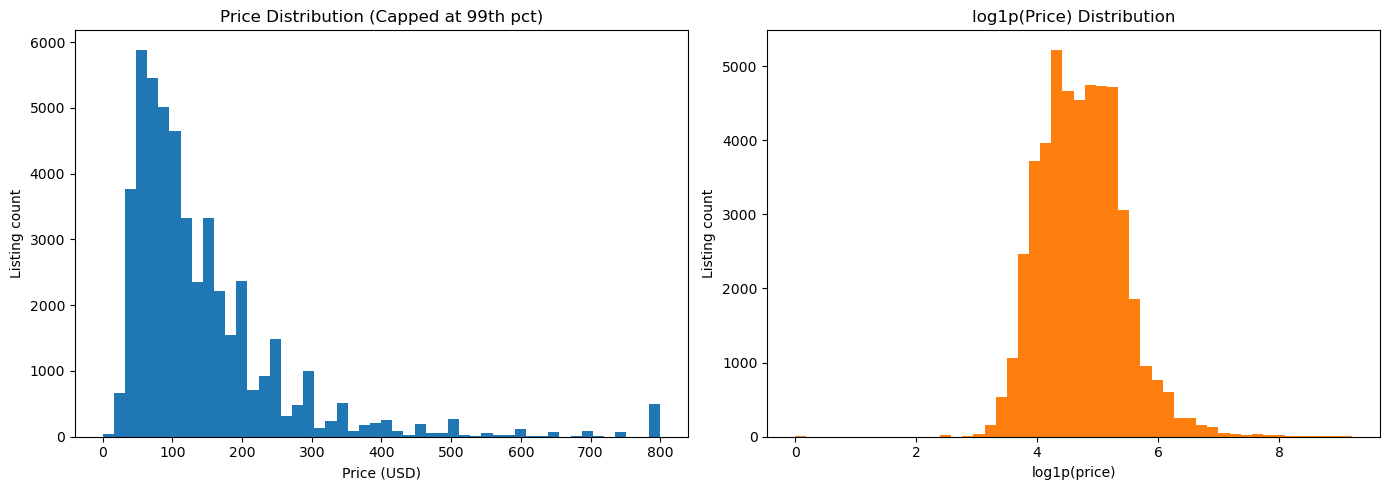

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price_for_viz'], bins=50, color='#1f77b4')
axes[0].set_title('Price Distribution (Capped at 99th pct)')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Listing count')

axes[1].hist(df['y_log'], bins=50, color='#ff7f0e')
axes[1].set_title('log1p(Price) Distribution')
axes[1].set_xlabel('log1p(price)')
axes[1].set_ylabel('Listing count')
plt.tight_layout()
plt.show()


**Note:** The left histogram (trimmed at the 99th percentile) remains right-skewed, while the `log1p(price)` histogram on the right is more symmetric, underscoring why we cap extreme prices for clarity.


/var/folders/kc/_419kb191q5bx79n2m5jb1080000gn/T/ipykernel_16574/1078280400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='price_for_viz', palette='Set2')


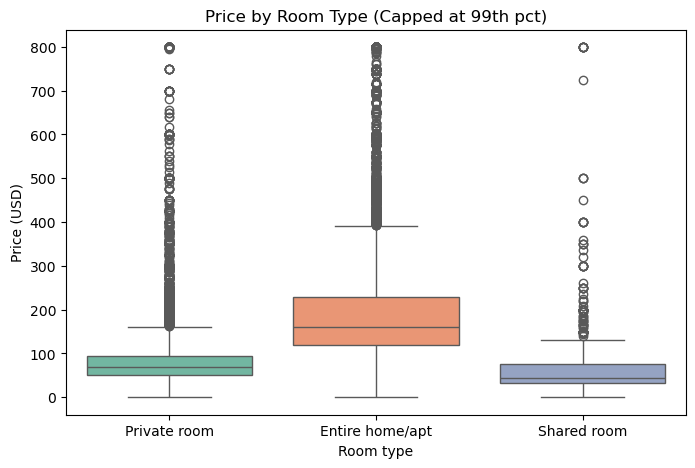

In [3]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='room_type', y='price_for_viz', palette='Set2')
plt.title('Price by Room Type (Capped at 99th pct)')
plt.xlabel('Room type')
plt.ylabel('Price (USD)')
plt.show()


**Note:** The room-type boxplot shows entire homes with higher medians and upper quartiles, marking them as the premium tier, whereas shared rooms stay uniformly low.


/var/folders/kc/_419kb191q5bx79n2m5jb1080000gn/T/ipykernel_16574/2183696862.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='neighbourhood_group', y='price_for_viz', palette='Set3')


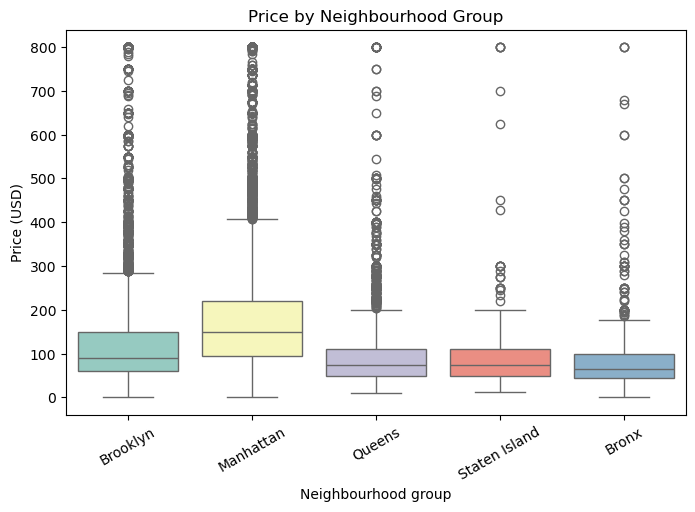

In [4]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='neighbourhood_group', y='price_for_viz', palette='Set3')
plt.title('Price by Neighbourhood Group')
plt.xlabel('Neighbourhood group')
plt.ylabel('Price (USD)')
plt.xticks(rotation=30)
plt.show()


**Note:** The borough boxplot highlights Manhattan's elevated box and numerous high outliers, Brooklyn next in line, while Queens/Bronx/Staten Island sit much lower.


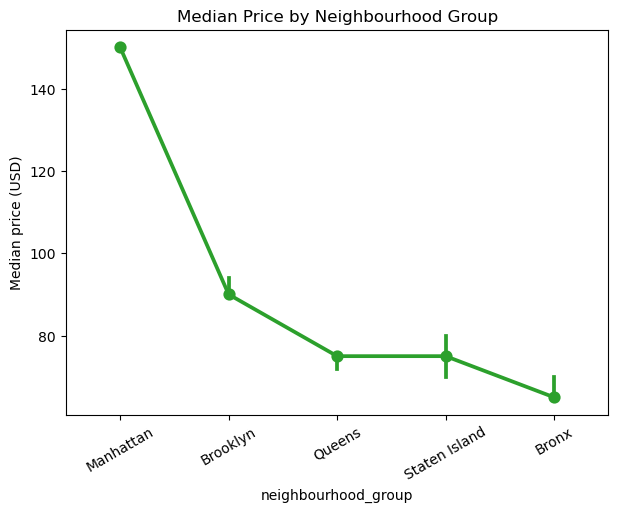

In [5]:

plt.figure(figsize=(7, 5))
order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.pointplot(
    data=df,
    x='neighbourhood_group',
    y='price',
    estimator=np.median,
    order=order,
    color='#2ca02c'
)
plt.title('Median Price by Neighbourhood Group')
plt.ylabel('Median price (USD)')
plt.xticks(rotation=30)
plt.show()


**Note:** The median point plot provides a robust comparison, letting you read each borough's typical nightly rate at a glance.


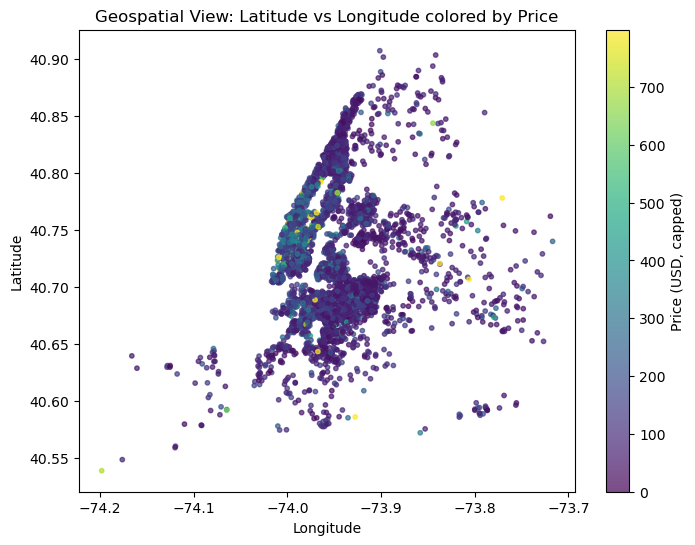

In [6]:

plt.figure(figsize=(8, 6))
sample = df.sample(n=min(5000, len(df)), random_state=42)
scatter = plt.scatter(
    sample['longitude'],
    sample['latitude'],
    c=sample['price_for_viz'],
    cmap='viridis',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Price (USD, capped)')
plt.title('Geospatial View: Latitude vs Longitude colored by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


**Note:** The latitude/longitude scatter plus colorbar reveals darker (higher-priced) clusters in Manhattan and parts of Brooklyn, confirming spatial concentration.
